# N2 potential energy curves: an introduction to CASSCF and multireference calculations in Forte2

This notebook uses the ground-state potential energy curve (PEC) of molecular nitrogen as a compact example of why multireference methods are needed. Near the equilibrium bond length, a single determinant is a useful starting point: the bonding orbitals are mostly occupied and the antibonding orbitals are mostly empty. As the N-N bond is stretched, those pictures become nearly degenerate. The exact wave function must describe several important electron arrangements at once.

That is where single-reference methods become fragile. UHF can break spin symmetry and converge to a qualitatively wrong dissociation limit, while UHF-based CCSD can become difficult to converge or can follow the wrong electronic state at stretched bond lengths. CASSCF gives us a controlled way to include the most important near-degenerate orbitals directly in the reference wave function.

## What this notebook demonstrates

We will:

1. Build UHF, DFT, and CCSD PECs for N2 as familiar single-reference baselines.
2. Inspect molecular orbitals from a Forte2 CASSCF calculation to choose a chemically motivated active space.
3. Compute a CASSCF(6,6) PEC for the N2 ground state.
4. Add dynamic correlation with DSRG-MRPT2 on top of the multireference CASSCF reference.

The important tutorial idea is not that N2 is exotic. It is that even a textbook diatomic molecule becomes multireference when bonds are broken.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import forte2
import psi4
from scipy.optimize import curve_fit

try:
    get_ipython().run_line_magic("config", "InlineBackend.figure_format = 'retina'")
except Exception:
    pass

HARTREE_TO_EV = 27.211399

In [34]:
def morse_potential(r, D, a, re, offset):
    """Morse potential used only as a compact visual fit to the computed points."""
    return D * (1 - np.exp(-a * (r - re)))**2 - offset


def fit_and_plot_pec(
    r_values,
    energies,
    title,
    initial_guess=(0.1, 4.0, 1.10, -109.3),
    xlim=(0.4, 7.0),
    ylim=None,
):
    """Fit a Morse curve to finite energy values and plot the PEC."""
    r_values = np.asarray(r_values, dtype=float)
    energies = np.asarray(energies, dtype=float)
    mask = np.isfinite(energies)

    if np.count_nonzero(mask) < 4:
        raise ValueError("Need at least four finite energy points for the Morse fit.")

    r_fit = r_values[mask]
    e_fit = energies[mask]
    grid = np.linspace(xlim[0], xlim[1], 500)

    popt, pcov = curve_fit(
        morse_potential,
        r_fit,
        e_fit,
        p0=initial_guess,
        maxfev=40_000_000,
    )
    yfit = morse_potential(grid, *popt)

    plt.plot(r_fit, e_fit, "o")
    plt.plot(grid, yfit)
    plt.title(title)
    plt.xlabel("R (Angstrom)")
    plt.ylabel("Energy (E$_{H}$)")
    plt.ticklabel_format(useOffset=False)
    plt.xlim(*xlim)
    if ylim is not None:
        plt.ylim(*ylim)

    dissociation_energy = (-np.min(yfit) + yfit[-1]) * HARTREE_TO_EV

    print(f"Predicted equilibrium bond length: {popt[2]:.4f} A")
    print("Experimental equilibrium bond length: 1.0977 A")
    print(f"Predicted bond dissociation energy: {dissociation_energy:.4f} eV")
    print("Experimental bond dissociation energy: 9.759 eV")

    return popt, pcov

## A single-reference starting point

We start with a Hartree-Fock calculation at the experimental equilibrium bond length. Hartree-Fock represents the electrons with one Slater determinant, so it is a natural first approximation and a useful source of orbitals. The limitation is already built in: one determinant cannot smoothly describe the simultaneous breaking of the three bonds in N2.

In [35]:
# A single RHF calculation at the experimental equilibrium geometry.
psi4.set_memory("500 MB")

n2 = psi4.geometry("""
N  0.0000  0.0000  0.0000
N  0.0000  0.0000  1.0977
""")

psi4.set_options({
    "basis": "cc-pVDZ",
    "df_basis_scf": "cc-pVTZ-JKFIT",
    "print": 0,
})

psi4.energy("scf")


  Memory set to 476.837 MiB by Python driver.

Scratch directory: /tmp/
PLANNING Atomic:  keywords={'DF_BASIS_SCF': 'CC-PVTZ-JKFIT', 'SCF__D_CONVERGENCE': 1e-08, 'E_CONVERGENCE': 1e-06, 'SCF__E_CONVERGENCE': 1e-08, 'SCF__INTS_TOLERANCE': 1e-12, 'MAXITER': 100, 'PRINT': 0, 'SCF__REFERENCE': 'UHF', 'CCENERGY__WFN': 'CCSD', 'CCTRANSORT__WFN': 'CCSD', 'function_kwargs': {}}
Compute energy(): method=scf, basis=cc-pvdz, molecule=default, nre=23.621830484494858


   => Libint2 <=

    Primary   basis highest AM E, G, H:  5, 5, 3
    Auxiliary basis highest AM E, G, H:  6, 6, 4
    Onebody   basis highest AM E, G, H:  -, -, -
    Solid Harmonics ordering:            Gaussian

*** tstart() called on LAPTOP-82M92BSS
*** at Mon May 18 11:15:55 2026

   => Loading Basis Set <=

    Name: CC-PVDZ
    Role: ORBITAL
    Keyword: BASIS
    atoms 1-2 entry N          line   168 file /home/prank/miniconda3/envs/forte2/share/psi4/basis/cc-pvdz.gbs 

   => Loading Basis Set <=

    Name: CC-PVTZ-JKFIT
    Role: JKFIT
    Keyword: DF_BASIS_SCF
    atoms 1-2 entry N          line   177 file /home/prank/miniconda3/envs/forte2/share/psi4/basis/cc-pvtz-jkfit.gbs 

  DFHelper Memory: AOs need 0.001 GiB; user supplied 0.349 GiB. 
  SCF_SUBTYPE=INCORE selected. In-core MEM_DF algorithm will be used.
  Using in-core AOs.


  ==> Pre-Iterations <==

  ==> Iterations <==

                           Total Energy        Delta E     RMS |[F,P]|

   @DF-UHF iter SAD:  -10

-108.95405951014817

## UHF PEC: useful, but not a reliable dissociation picture

Unrestricted Hartree-Fock gives the alpha and beta electrons separate orbital sets. This flexibility can lower the energy at stretched geometries, but it often does so by breaking spin symmetry. The curve may look smooth while no longer representing the correct singlet ground state.

In [36]:
N2_rlist = [
    0.70, 0.80, 0.90, 0.95, 1.00, 1.05, 1.0977, 1.15, 1.20, 1.25,
    1.30, 1.35, 1.40, 1.50, 1.60, 1.70, 1.80, 1.90, 2.00, 2.20,
    2.40, 2.60, 2.80, 3.00, 3.20, 3.40, 3.60, 3.80, 4.00, 4.20,
    4.40, 4.60, 4.80, 5.00,
]
HF_elist = []

for r in N2_rlist:
    psi4.core.clean()
    psi4.set_memory("500 MB")

    n2 = psi4.geometry(f"""
    N  0.0000  0.0000  0.0000
    N  0.0000  0.0000  {r}
    """)

    psi4.set_options({
        "basis": "cc-pVDZ",
        "df_basis_scf": "cc-pVTZ-JKFIT",
        "scf__reference": "uhf",
        "print": 0,
    })

    try:
        HF_elist.append(psi4.energy("scf"))
    except Exception as exc:
        print(f"UHF failed at R = {r:.2f} A: {exc}")
        HF_elist.append(np.nan)

HF_elist


  Memory set to 476.837 MiB by Python driver.

Scratch directory: /tmp/
PLANNING Atomic:  keywords={'DF_BASIS_SCF': 'CC-PVTZ-JKFIT', 'SCF__D_CONVERGENCE': 1e-08, 'E_CONVERGENCE': 1e-06, 'SCF__E_CONVERGENCE': 1e-08, 'SCF__INTS_TOLERANCE': 1e-12, 'MAXITER': 100, 'PRINT': 0, 'SCF__REFERENCE': 'UHF', 'CCENERGY__WFN': 'CCSD', 'CCTRANSORT__WFN': 'CCSD', 'function_kwargs': {}}
Compute energy(): method=scf, basis=cc-pvdz, molecule=default, nre=37.04240474690001


   => Libint2 <=

    Primary   basis highest AM E, G, H:  5, 5, 3
    Auxiliary basis highest AM E, G, H:  6, 6, 4
    Onebody   basis highest AM E, G, H:  -, -, -
    Solid Harmonics ordering:            Gaussian

*** tstart() called on LAPTOP-82M92BSS
*** at Mon May 18 11:15:58 2026

   => Loading Basis Set <=

    Name: CC-PVDZ
    Role: ORBITAL
    Keyword: BASIS
    atoms 1-2 entry N          line   168 file /home/prank/miniconda3/envs/forte2/share/psi4/basis/cc-pvdz.gbs 

   => Loading Basis Set <=

    Name: CC-PVTZ-JKFIT
    Role: JKFIT
    Keyword: DF_BASIS_SCF
    atoms 1-2 entry N          line   177 file /home/prank/miniconda3/envs/forte2/share/psi4/basis/cc-pvtz-jkfit.gbs 

  DFHelper Memory: AOs need 0.001 GiB; user supplied 0.349 GiB. 
  SCF_SUBTYPE=INCORE selected. In-core MEM_DF algorithm will be used.
  Using in-core AOs.


  ==> Pre-Iterations <==

  ==> Iterations <==

                           Total Energy        Delta E     RMS |[F,P]|

   @DF-UHF iter SAD:  -11

[-107.61337050211361,
 -108.4072222235883,
 -108.78270421579421,
 -108.87680583248407,
 -108.92976504265312,
 -108.95263455968076,
 -108.95405951014817,
 -108.9392860030014,
 -108.91397955111061,
 -108.88129104196841,
 -108.84381012223183,
 -108.80345556171679,
 -108.76163987308874,
 -108.67744116580249,
 -108.59630941964363,
 -108.52055215406044,
 -108.4509918145842,
 -108.38773029174548,
 -108.33053094707526,
 -108.23262733512722,
 -108.15344357802371,
 -108.08925468700471,
 -108.03694323295589,
 -107.9940455832829,
 -107.95868102310706,
 -107.92943606626281,
 -107.90522814578185,
 -107.88518350134062,
 -107.86855969378477,
 -107.85471257327825,
 -108.21984721000743,
 -108.21725914122617,
 -108.214926130558,
 -108.21280046038729]

Predicted equilibrium bond length: 1.0898 A
Experimental equilibrium bond length: 1.0977 A
Predicted bond dissociation energy: 25.8898 eV
Experimental bond dissociation energy: 9.759 eV


(array([  0.95146039,   2.00538644,   1.08982887, 108.96866249]),
 array([[ 1.75719917e-03, -3.78920632e-04, -4.20326226e-05,
          9.83170352e-04],
        [-3.78920632e-04,  1.11879945e-02, -1.61841466e-03,
          1.18605618e-03],
        [-4.20326226e-05, -1.61841466e-03,  3.04518996e-04,
         -2.08113135e-04],
        [ 9.83170352e-04,  1.18605618e-03, -2.08113135e-04,
          1.00184154e-03]]))

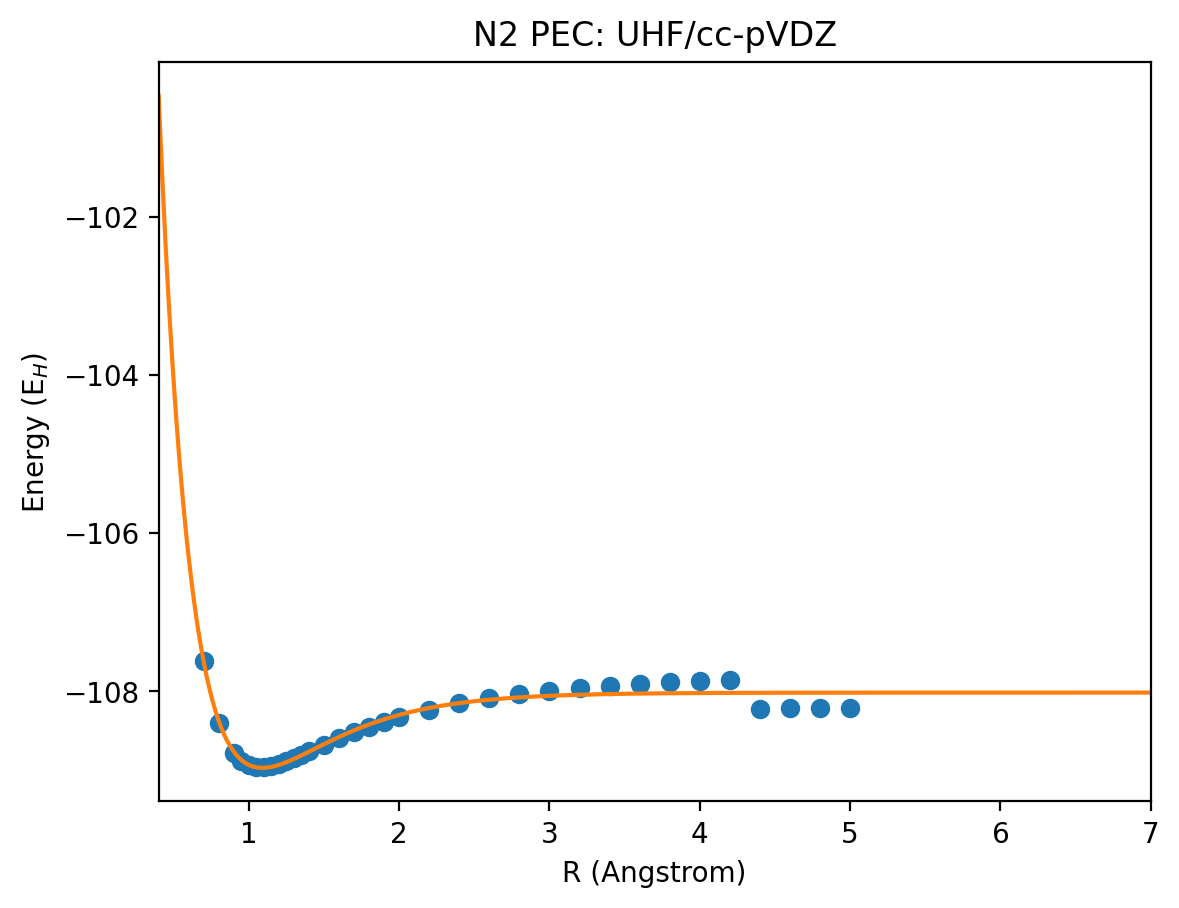

In [37]:
fit_and_plot_pec(
    N2_rlist,
    HF_elist,
    "N2 PEC: UHF/cc-pVDZ",
    initial_guess=(1.0, 1.0, 1.0, -100.0),
)

## A DFT comparison

B3LYP is included as another familiar single-reference baseline. It often gives reasonable equilibrium properties, but the core issue remains: standard Kohn-Sham calculations are also built from one determinant-like reference density and are not a substitute for an explicit multiconfigurational treatment of bond breaking.

In [38]:
DFT_elist = []

for r in N2_rlist:
    psi4.core.clean()
    psi4.set_memory("500 MB")

    n2 = psi4.geometry(f"""
    N  0.0000  0.0000  0.0000
    N  0.0000  0.0000  {r}
    """)

    psi4.set_options({
        "basis": "cc-pVDZ",
        "df_basis_scf": "cc-pVTZ-JKFIT",
        "scf__reference": "UKS",
        "print": 0,
    })

    try:
        DFT_elist.append(psi4.energy("b3lyp"))
    except Exception as exc:
        print(f"B3LYP failed at R = {r:.2f} A: {exc}")
        DFT_elist.append(np.nan)

#DFT_elist


  Memory set to 476.837 MiB by Python driver.

Scratch directory: /tmp/
PLANNING Atomic:  keywords={'DF_BASIS_SCF': 'CC-PVTZ-JKFIT', 'SCF__D_CONVERGENCE': 1e-08, 'E_CONVERGENCE': 1e-06, 'SCF__E_CONVERGENCE': 1e-08, 'SCF__INTS_TOLERANCE': 1e-12, 'MAXITER': 100, 'PRINT': 0, 'SCF__REFERENCE': 'UKS', 'CCENERGY__WFN': 'CCSD', 'CCTRANSORT__WFN': 'CCSD', 'function_kwargs': {}}
Compute energy(): method=b3lyp, basis=cc-pvdz, molecule=default, nre=37.04240474690001


   => Libint2 <=

    Primary   basis highest AM E, G, H:  5, 5, 3
    Auxiliary basis highest AM E, G, H:  6, 6, 4
    Onebody   basis highest AM E, G, H:  -, -, -
    Solid Harmonics ordering:            Gaussian

*** tstart() called on LAPTOP-82M92BSS
*** at Mon May 18 11:16:17 2026

   => Loading Basis Set <=

    Name: CC-PVDZ
    Role: ORBITAL
    Keyword: BASIS
    atoms 1-2 entry N          line   168 file /home/prank/miniconda3/envs/forte2/share/psi4/basis/cc-pvdz.gbs 

   => Loading Basis Set <=

    Name: CC-PVTZ-JKFIT
    Role: JKFIT
    Keyword: DF_BASIS_SCF
    atoms 1-2 entry N          line   177 file /home/prank/miniconda3/envs/forte2/share/psi4/basis/cc-pvtz-jkfit.gbs 

  DFHelper Memory: AOs need 0.001 GiB; user supplied 0.315 GiB. 
  SCF_SUBTYPE=INCORE selected. In-core MEM_DF algorithm will be used.
  Using in-core AOs.


  ==> Pre-Iterations <==

  ==> Iterations <==

                           Total Energy        Delta E     RMS |[F,P]|

   @DF-UKS iter SAD:  -11

Predicted equilibrium bond length: 1.1243 A
Experimental equilibrium bond length: 1.0977 A
Predicted bond dissociation energy: 18.5716 eV
Experimental bond dissociation energy: 9.759 eV


(array([  0.68252905,   2.07726021,   1.12430051, 109.54661498]),
 array([[ 7.71656317e-05, -4.83850378e-05, -2.09007573e-07,
          4.15407800e-05],
        [-4.83850378e-05,  7.66159404e-04, -1.21530277e-04,
          3.44162497e-05],
        [-2.09007573e-07, -1.21530277e-04,  2.31953748e-05,
         -8.82617353e-06],
        [ 4.15407800e-05,  3.44162497e-05, -8.82617353e-06,
          3.98219755e-05]]))

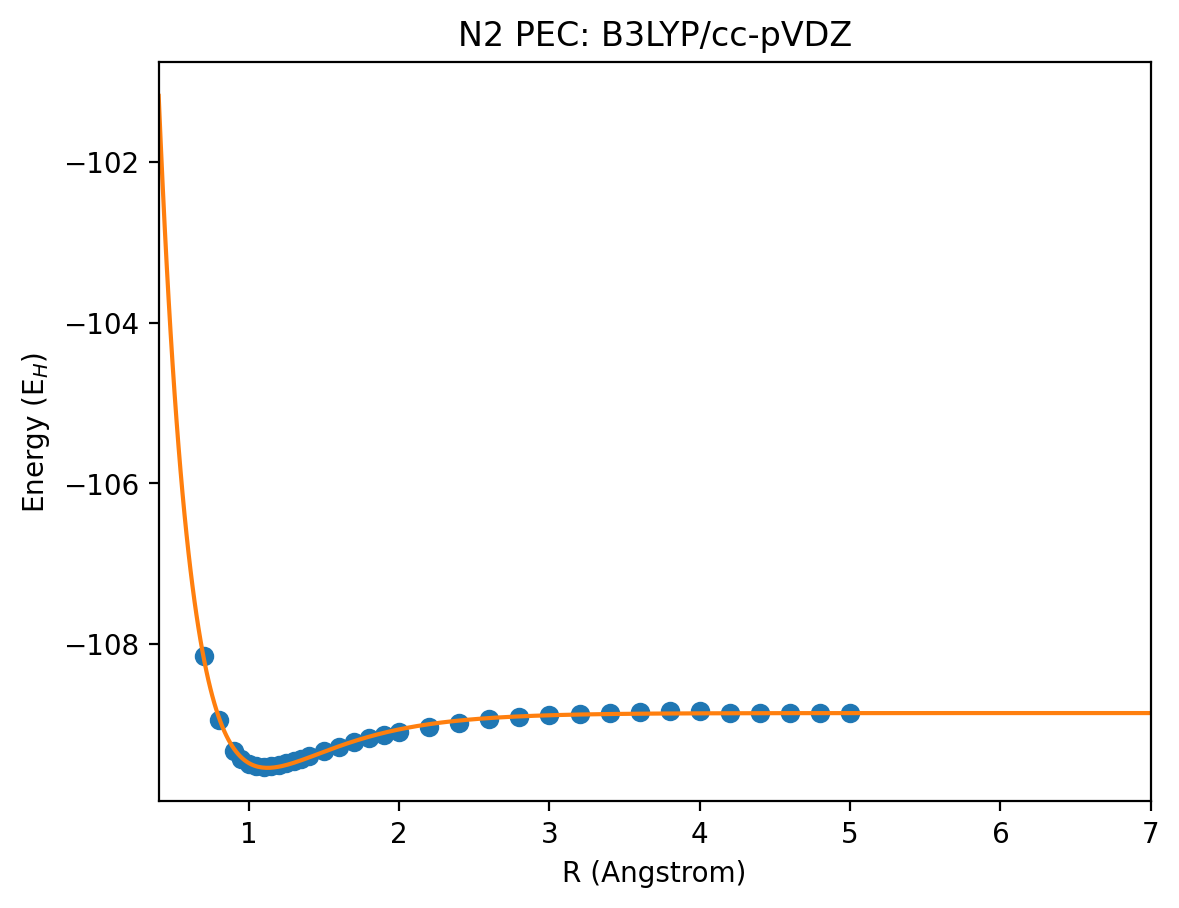

In [39]:
fit_and_plot_pec(
    N2_rlist,
    DFT_elist,
    "N2 PEC: B3LYP/cc-pVDZ",
    initial_guess=(1.0, 1.0, 1.0, -100.0),
)

## CCSD and the stretched-bond problem

CCSD is a powerful single-reference correlation method near equilibrium. However, its cluster amplitudes are defined relative to one reference determinant. When the bonding and antibonding orbitals become nearly degenerate, that reference is no longer qualitatively adequate, and CCSD may fail to converge or converge to the wrong state.

In [40]:
CCSD_rlist = [
    0.70, 0.80, 0.90, 0.95, 1.00, 1.05, 1.0977, 1.15, 1.20, 1.30,
    1.40, 1.50, 1.60, 1.70, 1.80, 1.90, 2.00, 2.20, 2.80, 3.00,
    3.20, 3.40,
]
CCSD_elist = []

for r in CCSD_rlist:
    psi4.core.clean()
    psi4.set_memory("800 MB")

    n2 = psi4.geometry(f"""
    N  0.0000  0.0000  0.0000
    N  0.0000  0.0000  {r}
    """)

    psi4.set_options({
        "basis": "cc-pVDZ",
        "df_basis_scf": "cc-pVTZ-JKFIT",
        "scf__reference": "UHF",
        "maxiter": 100,
        "print": 0,
    })

    try:
        CCSD_elist.append(psi4.energy("ccsd"))
    except Exception as exc:
        print(f"CCSD failed at R = {r:.2f} A: {exc}")
        CCSD_elist.append(np.nan)

CCSD_elist


  Memory set to 762.939 MiB by Python driver.

Scratch directory: /tmp/
PLANNING Atomic:  keywords={'DF_BASIS_SCF': 'CC-PVTZ-JKFIT', 'SCF__D_CONVERGENCE': 1e-08, 'E_CONVERGENCE': 1e-06, 'SCF__E_CONVERGENCE': 1e-08, 'SCF__INTS_TOLERANCE': 1e-12, 'MAXITER': 100, 'PRINT': 0, 'SCF__REFERENCE': 'UHF', 'CCENERGY__WFN': 'CCSD', 'CCTRANSORT__WFN': 'CCSD', 'function_kwargs': {}}
Compute energy(): method=ccsd, basis=cc-pvdz, molecule=default, nre=37.04240474690001


   => Libint2 <=

    Primary   basis highest AM E, G, H:  5, 5, 3
    Auxiliary basis highest AM E, G, H:  6, 6, 4
    Onebody   basis highest AM E, G, H:  -, -, -
    Solid Harmonics ordering:            Gaussian

*** tstart() called on LAPTOP-82M92BSS
*** at Mon May 18 11:16:56 2026

   => Loading Basis Set <=

    Name: CC-PVDZ
    Role: ORBITAL
    Keyword: BASIS
    atoms 1-2 entry N          line   168 file /home/prank/miniconda3/envs/forte2/share/psi4/basis/cc-pvdz.gbs 

  Using in-core PK algorithm.
   Calculation information:
      Number of atoms:                   2
      Number of AO shells:              12
      Number of primitives:             44
      Number of atomic orbitals:        30
      Number of basis functions:        28

      Integral cutoff                 1.00e-12
      Number of threads:                 1

  Performing in-core PK
  Using 165242 doubles for integral storage.
  We computed 3081 shell quartets total.
  Whereas there are 3081 unique shell qua

[-107.84734179738597,
 -108.65985483876206,
 -109.05463616049467,
 -109.15870878151335,
 -109.22192004704537,
 -109.25536548498359,
 -109.26721020067937,
 -109.26424963838284,
 -109.25061882669064,
 -109.20486851813884,
 -109.14838308309317,
 -109.0909648069501,
 -109.03772732752684,
 -108.9913649047432,
 -108.95364155278178,
 -108.9263749986344,
 -108.91191027064178,
 -108.92432908823139,
 -108.99235531583463,
 -109.00035656905081,
 -109.0053181662345,
 -109.00851664151307]

Predicted equilibrium bond length: 1.0867 A
Experimental equilibrium bond length: 1.0977 A
Predicted bond dissociation energy: 8.1715 eV
Experimental bond dissociation energy: 9.759 eV


(array([  0.3002982 ,   2.98599996,   1.08671347, 109.24525008]),
 array([[ 7.09822405e-04, -2.52739853e-03,  8.13511757e-05,
          3.13652139e-04],
        [-2.52739853e-03,  2.64636818e-02, -2.34337781e-03,
         -7.45033829e-04],
        [ 8.13511757e-05, -2.34337781e-03,  2.61863655e-04,
          2.11652843e-06],
        [ 3.13652139e-04, -7.45033829e-04,  2.11652843e-06,
          2.44031291e-04]]))

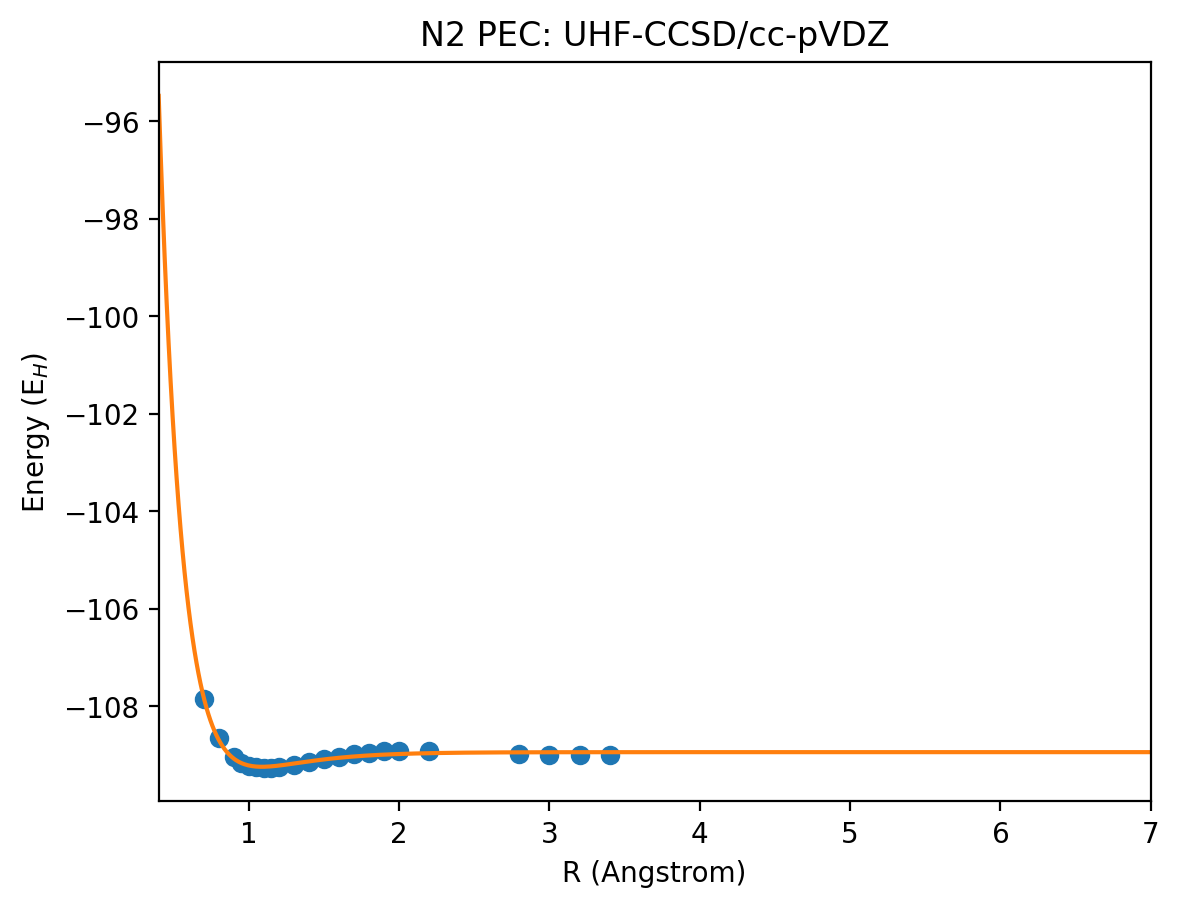

In [41]:
fit_and_plot_pec(
    CCSD_rlist,
    CCSD_elist,
    "N2 PEC: UHF-CCSD/cc-pVDZ",
    initial_guess=(0.1, 4.0, 1.10, -109.3),
)

The next cell deliberately probes a stretched geometry. It is written with `try`/`except` because failure to converge is part of the lesson, not a notebook error.

In [42]:
psi4.core.clean()
psi4.set_memory("800 MB")

n2 = psi4.geometry("""
N  0.0000  0.0000  0.0000
N  0.0000  0.0000  4.000
""")

psi4.set_options({
    "basis": "cc-pVDZ",
    "df_basis_scf": "cc-pVTZ-JKFIT",
    "scf__reference": "UHF",
    "maxiter": 100,
    "print": 0,
})

try:
    E = psi4.energy("ccsd")
    print(f"CCSD energy at 3.40 A: {E:.12f} Eh")
except Exception as exc:
    print("CCSD did not converge cleanly at 4.00 A.")
    print(exc)


  Memory set to 762.939 MiB by Python driver.

Scratch directory: /tmp/
PLANNING Atomic:  keywords={'DF_BASIS_SCF': 'CC-PVTZ-JKFIT', 'SCF__D_CONVERGENCE': 1e-08, 'E_CONVERGENCE': 1e-06, 'SCF__E_CONVERGENCE': 1e-08, 'SCF__INTS_TOLERANCE': 1e-12, 'MAXITER': 100, 'PRINT': 0, 'SCF__REFERENCE': 'UHF', 'CCENERGY__WFN': 'CCSD', 'CCTRANSORT__WFN': 'CCSD', 'function_kwargs': {}}
Compute energy(): method=ccsd, basis=cc-pvdz, molecule=default, nre=6.482420830707499


   => Libint2 <=

    Primary   basis highest AM E, G, H:  5, 5, 3
    Auxiliary basis highest AM E, G, H:  6, 6, 4
    Onebody   basis highest AM E, G, H:  -, -, -
    Solid Harmonics ordering:            Gaussian

*** tstart() called on LAPTOP-82M92BSS
*** at Mon May 18 11:18:04 2026

   => Loading Basis Set <=

    Name: CC-PVDZ
    Role: ORBITAL
    Keyword: BASIS
    atoms 1-2 entry N          line   168 file /home/prank/miniconda3/envs/forte2/share/psi4/basis/cc-pvdz.gbs 

  Using in-core PK algorithm.
   Calculation information:
      Number of atoms:                   2
      Number of AO shells:              12
      Number of primitives:             44
      Number of atomic orbitals:        30
      Number of basis functions:        28

      Integral cutoff                 1.00e-12
      Number of threads:                 1

  Performing in-core PK
  Using 165242 doubles for integral storage.
  We computed 2612 shell quartets total.
  Whereas there are 3081 unique shell qua

## Choosing an active space by inspecting orbitals

For CASSCF, we divide the orbitals into inactive core orbitals, active orbitals, and external virtual orbitals. The active orbitals are the ones whose occupations may change substantially along the reaction coordinate.

For N2 bond breaking, the minimal chemically sensible active space contains the valence bonding and antibonding orbitals associated with the triple bond:

- one sigma bonding orbital and one sigma antibonding orbital,
- two pi bonding orbitals,
- two pi antibonding orbitals.

That gives a CASSCF(6,6): six active electrons in six active orbitals. The cube-projection helper below writes one Forte2 orbital cube at a time from `mc.C[0]` and plots a signed 2D projection. This lets us inspect individual orbitals without building the larger mutual-correlation diagram.

In [43]:
import glob
import pathlib
import matplotlib.pyplot as plt
import numpy as np
from forte2.orbitals import write_orbital_cubes


def _read_cube_data(cube_file):
    """Read enough of a Gaussian cube file to recover the volumetric data."""
    with open(cube_file, "r") as f:
        f.readline()
        f.readline()

        natoms = abs(int(f.readline().split()[0]))

        shape = []
        for _ in range(3):
            shape.append(abs(int(f.readline().split()[0])))

        for _ in range(natoms):
            f.readline()

        values = np.fromiter(
            (float(x) for line in f for x in line.split()),
            dtype=float,
        )

    expected = int(np.prod(shape))
    if values.size < expected:
        raise ValueError(
            f"Cube file {cube_file} has {values.size} data values, expected {expected}"
        )

    return values[:expected].reshape(shape)


def _signed_max_projection(data, axis=2):
    """Project a signed orbital volume while preserving the larger-magnitude sign."""
    axis = int(axis)
    max_idx = np.argmax(np.abs(data), axis=axis)
    return np.take_along_axis(
        data,
        np.expand_dims(max_idx, axis),
        axis=axis,
    ).squeeze(axis)


def plot_orbital_cube_projection(
    system,
    C,
    orbital,
    orbitals_filepath="n2_active_space_orbitals",
    projection_axis=1,
    cmap="seismic",
    levels=14,
    figsize=(4, 4),
    title=None,
    show_colorbar=False,
    output_file=None,
):
    """Write one Forte2 orbital cube and plot a signed 2D max projection.

    `C` can be the Forte2 MO coefficient matrix `mc.C[0]`. The `orbital`
    argument is the orbital index passed to `write_orbital_cubes`.
    """
    orbitals_filepath = pathlib.Path(orbitals_filepath)
    orbitals_filepath.mkdir(parents=True, exist_ok=True)

    write_orbital_cubes(
        system,
        C,
        indices=[orbital],
        filepath=orbitals_filepath,
        prefix="orbital",
    )

    cube_file = orbitals_filepath / f"orbital_{orbital}.cube"
    if not cube_file.exists():
        cube_files = sorted(glob.glob(str(orbitals_filepath / "orbital_*.cube")))
        if not cube_files:
            raise FileNotFoundError(f"No cube file was written in {orbitals_filepath}")
        cube_file = pathlib.Path(cube_files[0])

    data = _read_cube_data(cube_file)
    plane = _signed_max_projection(data, axis=projection_axis)

    vmax = float(np.max(np.abs(plane)))
    if vmax == 0.0:
        vmax = 1.0

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(
        plane.T,
        origin="lower",
        cmap=cmap,
        vmin=-vmax,
        vmax=vmax,
        interpolation="bilinear",
    )

    contour_levels = np.linspace(-vmax, vmax, 2 * levels + 1)
    contour_levels = contour_levels[contour_levels != 0.0]
    if contour_levels.size:
        ax.contour(
            plane.T,
            levels=contour_levels,
            colors="black",
            linewidths=0.35,
            alpha=0.45,
        )

    ax.set_axis_off()
    ax.set_title(f"Orbital {orbital}" if title is None else title)

    if show_colorbar:
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label("MO amplitude", rotation=270, labelpad=15)

    if output_file is not None:
        fig.savefig(output_file, bbox_inches="tight", dpi=300)

    plt.show()
    return fig, ax, cube_file

Run a small CASSCF calculation at the equilibrium geometry. We use four core orbitals and six active orbitals. With this indexing convention, the active orbitals are expected to be orbitals 4 through 9.

In [19]:
xyz = """
N 0.0000 0.0000 0.0000
N 1.0977 0.0000 0.0000
"""

system = forte2.System(
    xyz=xyz,
    basis_set="cc-pVDZ",
    auxiliary_basis_set="cc-pVTZ-JKFIT",
)

rhf = forte2.RHF(charge=0)(system)
rhf.run()

ci = forte2.CISolver(
    forte2.State(nel=14, multiplicity=1, ms=0.0),
    active_orbitals=6,
    core_orbitals=4,
    nroots=6,
)
mc = forte2.MCOptimizer(ci)(rhf)
mc.run()

Point group symmetry detection not performed. Running in C1 symmetry.
Principal Atomic Positions (a.u.):
   N   0.00000000   0.00000000   0.00000000
   N   2.07435237   0.00000000   0.00000000
Parsed 2 atoms with basis set of 28 functions.
  Max eigenvalue: 3.101e+00
  Min eigenvalue: 6.136e-03
  Condition number: 5.054e+02
  Inverse condition number: 1.978e-03
  Number of discarded eigenvalues: 0
  Number of kept eigenvalues: 28
  Largest discarded eigenvalue: 0.000e+00
  Smallest kept eigenvalue: 6.136e-03
Number of electrons: 14
Number of alpha electrons: 7
Number of beta electrons: 7
Ms: 0
Total charge: 0
Number of basis functions: 28
Number of orthogonalized basis functions: 28
Number of auxiliary basis functions: 158
Energy convergence criterion: 1.000000e-09
Density convergence criterion: 1.000000e-06
DIIS acceleration: True

==> RHF SCF ROUTINE <==
Memory requirements: 0.00 GB (doubled due to storing B_nPm)
Number of system basis functions: 28
Number of auxiliary basis function

MCOptimizer(ci_solver=CISolver(states=State(multiplicity=1, ms=0.0, nel=14, system=None, charge=0, gas_min=[], gas_max=[], symmetry=0, symmetry_label=None, na=7, nb=7, twice_ms=0), nroots=6, weights=[[0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666]], mo_space=MOSpace(nmo=28, active_orbitals=[[4, 5, 6, 7, 8, 9]], core_orbitals=[0, 1, 2, 3], frozen_core_orbitals=[], frozen_virtual_orbitals=[]), frozen_core_orbitals=None, core_orbitals=4, active_orbitals=6, frozen_virtual_orbitals=None, die_if_not_converged=False, first_run=False, executed=True, ci_params=CIParams(ci_algorithm='hz', ci_builder_memory=1024, energy_shift=None), davidson_liu_params=DavidsonLiuParams(guess_per_root=2, ndets_per_guess=10, collapse_per_root=2, basis_per_root=4, maxiter=100, e_tol=1e-12, r_tol=1e-06), do_test_rdms=False, log_level=4), active_frozen_orbitals=None, freeze_inter_gas_rots=False, maxiter=50, e_tol=1e-08, g_tol=1e-07, die_if

Change `orbital_to_inspect` and re-run the cell to inspect one orbital at a time. For the N2 active space, the orbitals should appear as the sigma and pi bonding/antibonding valence orbitals. If an orbital is core-like or high-lying/Rydberg-like, it usually does not belong in this minimal bond-breaking active space.


Generating cube files with the following parameters:
  Grid origin: (-4.000, -4.000, -4.000)
  Grid points: 51 x 40 x 40 points.
  Scaled axes: [(0.2, 0, 0), (0, 0.2, 0), (0, 0, 0.2)]
  Orbitals: [4]



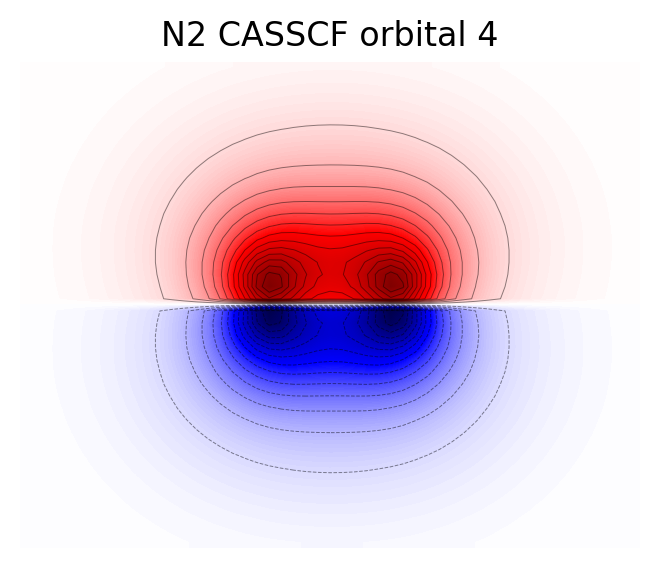

(<Figure size 400x400 with 1 Axes>,
 <Axes: title={'center': 'N2 CASSCF orbital 4'}>,
 PosixPath('n2_active_space_orbitals/orbital_4.cube'))

In [20]:
# Change this index to inspect a different orbital.
orbital_to_inspect = 4

plot_orbital_cube_projection(
    system=system,
    C=mc.C[0],
    orbital=orbital_to_inspect,
    projection_axis=1,
    title=f"N2 CASSCF orbital {orbital_to_inspect}",
)

The optional loop below is useful while building intuition. In a polished calculation, inspect the orbitals one by one and confirm that the selected active space follows the same chemical character along the PEC.

In [ ]:
# Optional: inspect the full valence active space one orbital at a time.
# In this setup, core_orbitals=4 and active_orbitals=6, so the active orbitals
# are expected to be indices 4, 5, 6, 7, 8, and 9.
for orbital in range(4, 10):
    plot_orbital_cube_projection(
        system=system,
        C=mc.C[0],
        orbital=orbital,
        projection_axis=1,
        title=f"Candidate active orbital {orbital}",
    )

## CASSCF(6,6) PEC

CASSCF optimizes both the active-space configuration interaction coefficients and the molecular orbitals. Because the active space includes the valence bonding and antibonding orbitals, the reference can smoothly change character as the N-N bond stretches.

In [44]:
N2_rlist = [
    0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 1.00, 1.05, 1.0977, 1.15,
    1.20, 1.30, 1.40, 1.50, 1.60, 1.70, 1.80, 1.90, 2.00, 2.20,
    2.40, 2.60, 2.80, 3.00, 3.20, 3.40, 3.60, 3.80, 4.00, 4.20,
    4.40, 4.60, 4.80, 5.00,
]
CAS_elist_0 = []
CAS_elist_1 = []

for r in N2_rlist:
    xyz = f"""
    N 0.000 0.000 0.000
    N 0.000 0.000 {r}
    """

    system = forte2.System(
        xyz=xyz,
        basis_set="cc-pVDZ",
        auxiliary_basis_set="cc-pVTZ-JKFIT",
    )

    rhf = forte2.RHF(charge=0)(system)
    rhf.run()

    ci = forte2.CISolver(
        forte2.State(nel=14, multiplicity=1, ms=0.0),
        active_orbitals=6,
        core_orbitals=4,
        nroots=6,
    )
    mc = forte2.MCOptimizer(ci, maxiter=100, micro_maxiter=100)(rhf)
    mc.run()

    CAS_elist_0.append(ci.E[0])
    CAS_elist_1.append(ci.E[1])

CAS_elist_0
CAS_elist_1

Point group symmetry detection not performed. Running in C1 symmetry.
Principal Atomic Positions (a.u.):
   N   0.00000000   0.00000000   0.00000000
   N   0.00000000   0.00000000   1.32280829
Parsed 2 atoms with basis set of 28 functions.
  Max eigenvalue: 3.266e+00
  Min eigenvalue: 8.208e-04
  Condition number: 3.980e+03
  Inverse condition number: 2.513e-04
  Number of discarded eigenvalues: 0
  Number of kept eigenvalues: 28
  Largest discarded eigenvalue: 0.000e+00
  Smallest kept eigenvalue: 8.208e-04
Number of electrons: 14
Number of alpha electrons: 7
Number of beta electrons: 7
Ms: 0
Total charge: 0
Number of basis functions: 28
Number of orthogonalized basis functions: 28
Number of auxiliary basis functions: 158
Energy convergence criterion: 1.000000e-09
Density convergence criterion: 1.000000e-06
DIIS acceleration: True

==> RHF SCF ROUTINE <==
Memory requirements: 0.00 GB (doubled due to storing B_nPm)
Number of system basis functions: 28
Number of auxiliary basis function

[np.float64(-106.99104616407938),
 np.float64(-107.49685206669079),
 np.float64(-107.86661500536465),
 np.float64(-108.13371402539862),
 np.float64(-108.32151874281861),
 np.float64(-108.4412618313621),
 np.float64(-108.54815641968356),
 np.float64(-108.62754881458858),
 np.float64(-108.67833538531607),
 np.float64(-108.71398860119068),
 np.float64(-108.73391886356029),
 np.float64(-108.7468260006793),
 np.float64(-108.73901100815753),
 np.float64(-108.72139940990267),
 np.float64(-108.70103078476917),
 np.float64(-108.67873081453179),
 np.float64(-108.65763778184896),
 np.float64(-108.63873969253329),
 np.float64(-108.62388284625978),
 np.float64(-108.60093043369528),
 np.float64(-108.5848411048773),
 np.float64(-108.57521325097306),
 np.float64(-108.56932915101979),
 np.float64(-108.5662393735661),
 np.float64(-108.56532223984775),
 np.float64(-108.56530160477726),
 np.float64(-108.56522456606166),
 np.float64(-108.5651606156798),
 np.float64(-108.56507356773555),
 np.float64(-108.56

Predicted equilibrium bond length: 1.1212 A
Experimental equilibrium bond length: 1.0977 A
Predicted bond dissociation energy: 7.6306 eV
Experimental bond dissociation energy: 9.759 eV


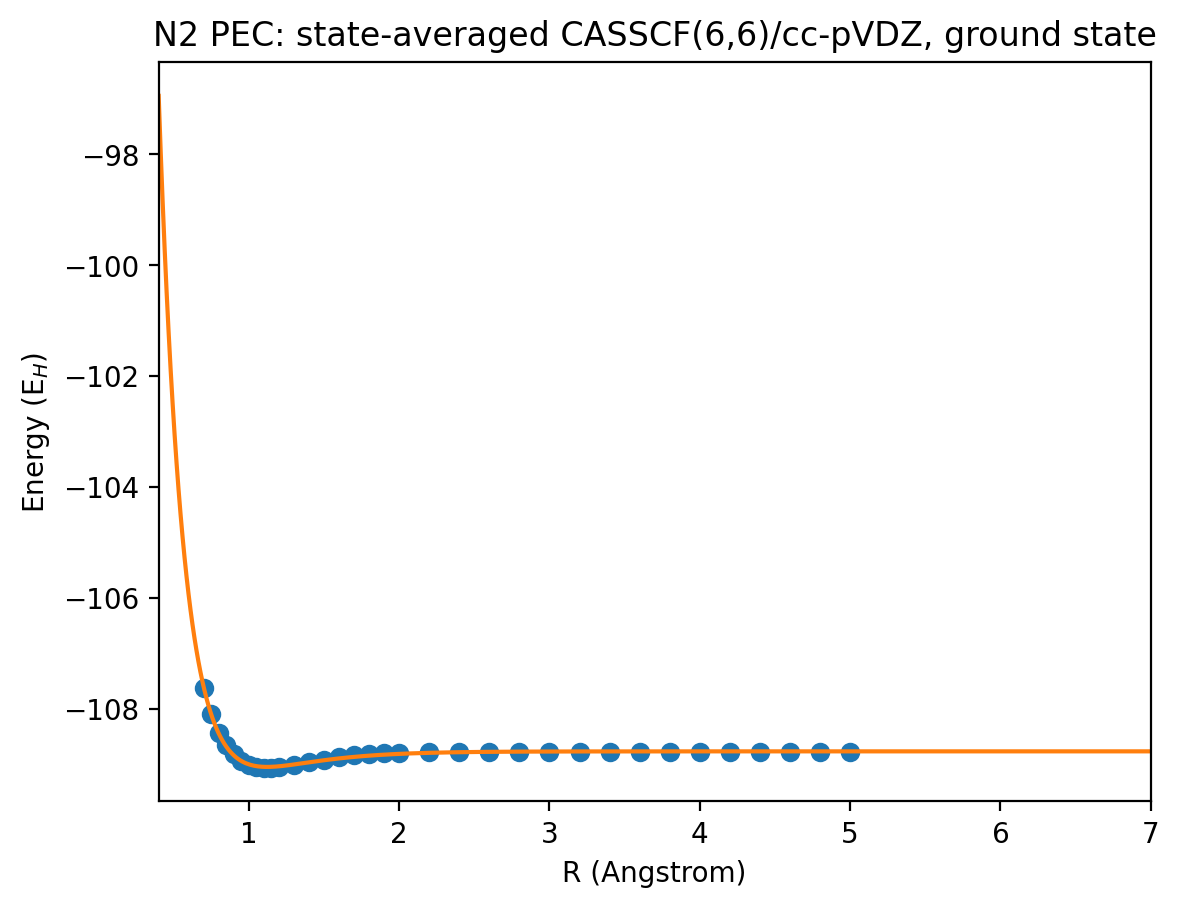

In [46]:
popt0, pcov0 = fit_and_plot_pec(
    N2_rlist,
    CAS_elist_0,
    "N2 PEC: state-averaged CASSCF(6,6)/cc-pVDZ, ground state",
    initial_guess=(0.1, 4.0, 1.10, -109.3),
)

#popt1, pcov1 = fit_and_plot_pec(
#    N2_rlist,
#    CAS_elist_1,
#    "N2 PEC: state-averaged CASSCF(6,6)/cc-pVDZ, first excited root",
#    initial_guess=(0.1, 4.0, 1.10, -109.3),
#)

## Adding dynamic correlation with DSRG-MRPT2

CASSCF captures static, or nondynamic, correlation from near-degenerate configurations. It does not recover most of the dynamic correlation from electron-electron avoidance outside the active space. Forte2 can add that missing correlation with multireference perturbation theory, here using DSRG-MRPT2 on top of the CASSCF reference.

In [48]:
DSRG_elist = []

for r in N2_rlist:
    xyz = f"""
    N 0.000 0.000 0.000
    N 0.000 0.000 {r}
    """

    system = forte2.System(
        xyz=xyz,
        basis_set="cc-pVDZ",
        auxiliary_basis_set="cc-pVTZ-JKFIT",
    )
    rhf = forte2.RHF(charge=0)(system)
    rhf.run()

    ci = forte2.CISolver(
        forte2.State(nel=14, multiplicity=1, ms=0.0),
        active_orbitals=6,
        core_orbitals=4,
        nroots=6,
    )
    mc = forte2.MCOptimizer(ci, maxiter=100, micro_maxiter=100)(rhf)
    mc.run()

    dsrg = forte2.dsrg.DSRG_MRPT2(flow_param=0.5, relax_reference="once")(mc)
    dsrg.run()
    DSRG_elist.append(dsrg.E_relaxed_ref)

DSRG_elist

Point group symmetry detection not performed. Running in C1 symmetry.
Principal Atomic Positions (a.u.):
   N   0.00000000   0.00000000   0.00000000
   N   0.00000000   0.00000000   1.32280829
Parsed 2 atoms with basis set of 28 functions.
  Max eigenvalue: 3.266e+00
  Min eigenvalue: 8.208e-04
  Condition number: 3.980e+03
  Inverse condition number: 2.513e-04
  Number of discarded eigenvalues: 0
  Number of kept eigenvalues: 28
  Largest discarded eigenvalue: 0.000e+00
  Smallest kept eigenvalue: 8.208e-04
Number of electrons: 14
Number of alpha electrons: 7
Number of beta electrons: 7
Ms: 0
Total charge: 0
Number of basis functions: 28
Number of orthogonalized basis functions: 28
Number of auxiliary basis functions: 158
Energy convergence criterion: 1.000000e-09
Density convergence criterion: 1.000000e-06
DIIS acceleration: True

==> RHF SCF ROUTINE <==
Memory requirements: 0.00 GB (doubled due to storing B_nPm)
Number of system basis functions: 28
Number of auxiliary basis function

[np.float64(-107.27358567341908),
 np.float64(-107.78130253704545),
 np.float64(-108.15056903370339),
 np.float64(-108.41678663279698),
 np.float64(-108.60566685607778),
 np.float64(-108.74913149806456),
 np.float64(-108.84753848298135),
 np.float64(-108.91241483327008),
 np.float64(-108.95184010613058),
 np.float64(-108.97644240006724),
 np.float64(-108.98674509941722),
 np.float64(-108.98276127461953),
 np.float64(-108.96138883256013),
 np.float64(-108.93363040725794),
 np.float64(-108.90411716842226),
 np.float64(-108.88101718012892),
 np.float64(-108.85818639939),
 np.float64(-108.84111807484173),
 np.float64(-108.82534637764935),
 np.float64(-108.80728862160517),
 np.float64(-108.7956181126515),
 np.float64(-108.78837533194057),
 np.float64(-108.78459943873479),
 np.float64(-108.78254786546405),
 np.float64(-108.78121701168118),
 np.float64(-108.78096171790114),
 np.float64(-108.78076849166854),
 np.float64(-108.78055230211899),
 np.float64(-108.78042955002329),
 np.float64(-108.7

In [ ]:
fit_and_plot_pec(
    N2_rlist,
    DSRG_elist,
    "N2 PEC: DSRG-MRPT2/cc-pVDZ on a CASSCF(6,6) reference",
    initial_guess=(5.0, 5.0, 1.1, -150.0),
    xlim=(0.4, 7.0),
    ylim=(-109.5, -105.0),
)

## Takeaways

At short bond lengths, single-reference methods can be accurate and efficient. At stretched bond lengths, the N2 ground state requires more than one important electron configuration. UHF may break symmetry, and CCSD may stop being a reliable black-box correction to a single determinant.

CASSCF addresses the qualitative failure by putting the near-degenerate valence orbitals into the active space. The orbital visualization step is therefore not decorative: it is how we check that the active space contains the orbitals responsible for the chemistry we want to describe.